In [60]:
import os
import tqdm
import time
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim.lr_scheduler import _LRScheduler
import torch.optim as optim
from torch.utils import data as torch_data

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import copy

In [61]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


# DatacenterDataset code

In [63]:
class DatacenterDataset(Dataset):
    def __init__(self, src, trg, class_names):
        self.src = torch.tensor(src, dtype=torch.float32)
        self.trg = torch.tensor(trg, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]

In [64]:
class DatacenterTwoTowerDataset(torch_data.Dataset):
    def __init__(self, X_gpu, X_cpu, y, class_names):
        self.X_gpu = torch.tensor(X_gpu, dtype=torch.float32)
        self.X_cpu = torch.tensor(X_cpu, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_gpu[idx], self.X_cpu[idx], self.y[idx]

# Load ML Data


In [65]:
seed = 2022
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

max_workers = 0
batch_size = 32

In [66]:
def split_data_combined_dataset(npz_path):

  ml_data = np.load(npz_path)
  X, y, model = ml_data["X"], ml_data["y"], ml_data["model"]

  print(X.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X, y):
      X_train_val, X_test = X[train_val_idx], X[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_train_val, y_train_val):
      X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

  print("Train:", X_train.shape, y_train.shape)
  print("Val:  ", X_val.shape, y_val.shape)
  print("Test: ", X_test.shape, y_test.shape)

  n_classes = len(np.unique(y_train))

  # Standardize using train only
  scaler = StandardScaler()

  X_train = scaler.fit_transform(
      X_train.reshape(-1, X_train.shape[-1])
  ).reshape(X_train.shape)

  X_val = scaler.transform(
      X_val.reshape(-1, X_val.shape[-1])
  ).reshape(X_val.shape)

  X_test = scaler.transform(
      X_test.reshape(-1, X_test.shape[-1])
  ).reshape(X_test.shape)

  # Build datasets
  dset_train = DatacenterDataset(X_train, y_train, class_names)
  dset_val = DatacenterDataset(X_val, y_val, class_names)
  dset_test = DatacenterDataset(X_test, y_test, class_names)

  train_dl_combined = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_combined = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_combined = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )
  return train_dl_combined, val_dl_combined, test_dl_combined

In [67]:
def split_data_separate_dataset(npz_path):

  ml_data = np.load(npz_path)
  X_gpu = ml_data["X_gpu"]
  X_cpu = ml_data["X_cpu"]
  y = ml_data["y"]
  model = ml_data["model"]

  print(X_gpu.shape, X_cpu.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X_gpu, y):
      X_gpu_train_val, X_gpu_test = X_gpu[train_val_idx], X_gpu[test_idx]
      X_cpu_train_val, X_cpu_test = X_cpu[train_val_idx], X_cpu[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]
      model_train_val, model_test = model[train_val_idx], model[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_gpu_train_val, y_train_val):
      X_gpu_train, X_gpu_val = X_gpu_train_val[train_idx], X_gpu_train_val[val_idx]
      X_cpu_train, X_cpu_val = X_cpu_train_val[train_idx], X_cpu_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]
      model_train, model_val = model_train_val[train_idx], model_train_val[val_idx]

  print("GPU train:", X_gpu_train.shape)
  print("CPU train:", X_cpu_train.shape)
  print("y train:  ", y_train.shape)

  print("GPU val:", X_gpu_val.shape)
  print("CPU val:", X_cpu_val.shape)
  print("y val:  ", y_val.shape)

  print("GPU test:", X_gpu_test.shape)
  print("CPU test:", X_cpu_test.shape)
  print("y test:  ", y_test.shape)

  n_classes = len(np.unique(y_train))

  gpu_scaler = StandardScaler()
  cpu_scaler = StandardScaler()

  X_gpu_train = gpu_scaler.fit_transform(
      X_gpu_train.reshape(-1, X_gpu_train.shape[-1])
  ).reshape(X_gpu_train.shape)

  X_gpu_val = gpu_scaler.transform(
      X_gpu_val.reshape(-1, X_gpu_val.shape[-1])
  ).reshape(X_gpu_val.shape)

  X_gpu_test = gpu_scaler.transform(
      X_gpu_test.reshape(-1, X_gpu_test.shape[-1])
  ).reshape(X_gpu_test.shape)


  X_cpu_train = cpu_scaler.fit_transform(
      X_cpu_train.reshape(-1, X_cpu_train.shape[-1])
  ).reshape(X_cpu_train.shape)

  X_cpu_val = cpu_scaler.transform(
      X_cpu_val.reshape(-1, X_cpu_val.shape[-1])
  ).reshape(X_cpu_val.shape)

  X_cpu_test = cpu_scaler.transform(
      X_cpu_test.reshape(-1, X_cpu_test.shape[-1])
  ).reshape(X_cpu_test.shape)

  dset_train = DatacenterTwoTowerDataset(X_gpu_train, X_cpu_train, y_train, class_names)
  dset_val = DatacenterTwoTowerDataset(X_gpu_val, X_cpu_val, y_val, class_names)
  dset_test = DatacenterTwoTowerDataset(X_gpu_test, X_cpu_test, y_test, class_names)

  train_dl_sep = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_sep = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_sep = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  return train_dl_sep, val_dl_sep, test_dl_sep

In [68]:
data_directory_path_combined = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED"
data_directory_path_separate = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE"

combined_datasets = []
separated_datasets = []

for _file in os.listdir(data_directory_path_combined):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_combined, _file)
  train_dl_combined, val_dl_combined, test_dl_combined = split_data_combined_dataset(_filepath)
  combined_datasets.append({"name": _file, "train_dl": train_dl_combined, "val_dl": val_dl_combined, "test_dl": test_dl_combined})

for _file in os.listdir(data_directory_path_separate):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_separate, _file)
  train_dl_separate, val_dl_separate, test_dl_separate = split_data_separate_dataset(_filepath)
  separated_datasets.append({"name": _file, "train_dl": train_dl_separate, "val_dl": val_dl_separate, "test_dl": test_dl_separate})



(18238, 540, 15) (18238,) (18238,)
Train: (11672, 540, 15) (11672,)
Val:   (2918, 540, 15) (2918,)
Test:  (3648, 540, 15) (3648,)
(17767, 540, 15) (17767,) (17767,)
Train: (11370, 540, 15) (11370,)
Val:   (2843, 540, 15) (2843,)
Test:  (3554, 540, 15) (3554,)
(17728, 540, 15) (17728,) (17728,)
Train: (11345, 540, 15) (11345,)
Val:   (2837, 540, 15) (2837,)
Test:  (3546, 540, 15) (3546,)
(17725, 540, 15) (17725,) (17725,)
Train: (11344, 540, 15) (11344,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17741, 540, 15) (17741,) (17741,)
Train: (11353, 540, 15) (11353,)
Val:   (2839, 540, 15) (2839,)
Test:  (3549, 540, 15) (3549,)
(17724, 540, 15) (17724,) (17724,)
Train: (11343, 540, 15) (11343,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17733, 540, 15) (17733,) (17733,)
Train: (11348, 540, 15) (11348,)
Val:   (2838, 540, 15) (2838,)
Test:  (3547, 540, 15) (3547,)
(18238, 540, 7) (18238, 7, 8) (18238,) (18238,)
GPU train: (11672, 540, 7)
CPU train: (116

In [69]:
class_names_combined = test_dl_combined.dataset.class_names
print(class_names_combined)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


In [70]:
class_names_separate = test_dl_separate.dataset.class_names
print(class_names_separate)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


# Define Model(s)

In [71]:
class PositionalEncoding(nn.Module):
  """
  Transformers process sequences all at once, so they lack inherent knowledge
  of token order. We must inject some information about the relative and absolute
  position of the tokens in the sequence. In this function, we add fixed positional
  encoding vector using sine and cosine waves.
  """
  def __init__(self, transform_embed_dim, dropout=0.0, max_len=5000):
    """
    Args:
      transform_embed_dim: the embed dimension.
      dropout: the dropout value.
      max_len: the maximum length of the incoming sequence.
    """

    super().__init__()

    self.dropout = nn.Dropout(p=dropout)

    pe = torch.zeros(max_len, transform_embed_dim)
    # pe shape: [max_len, transform_embed_dim]

    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    # position shape: [max_len, 1]

    div_term = torch.exp(
        torch.arange(0, transform_embed_dim, 2).float()
        * (-math.log(10000.0) / transform_embed_dim)
    )
    # div_term shape: [ceil(transform_embed_dim / 2)]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    # `[:pe[:, 1::2].shape[1]]` makes the code safer if `transform_embed_dim` is odd.
    # Ex. if `transform_embed_dim` == 15, the sine side has 8 dimensions and the cosine side
    # has 7 dimensions. This prevents a shape mismatch.

    # Add batch dimension so it can broadcast across batch:
    # [1, max_len, transform_embed_dim]
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    """
    Args:
      x: the sequence fed to the positional encoder model.

    Input shape:
        x: [batch_size, seq_len, transform_embed_dim]

    Output shape:
        x + positional encoding: [batch_size, seq_len, transform_embed_dim]

    Examples:
      >>> output = pos_encoder(x)
    """
    seq_len = x.size(1)
    x = x + self.pe[:, :seq_len, :]
    return self.dropout(x)

In [72]:
class TransformerEncoderLayerWithAttention(nn.Module):
    def __init__(
        self,
        transform_embed_dim,
        num_heads,
        dim_feedforward=128,
        dropout=0.1,
        activation="gelu",
        norm_first=True,
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=transform_embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.linear1 = nn.Linear(transform_embed_dim, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, transform_embed_dim)

        self.norm1 = nn.LayerNorm(transform_embed_dim)
        self.norm2 = nn.LayerNorm(transform_embed_dim)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        if activation == "relu":
            self.activation = F.relu
        elif activation == "gelu":
            self.activation = F.gelu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        self.norm_first = norm_first
        self.capture_attention = False
        self.attn_weights = None

        if self.capture_attention:
          print("capturing attention")

    def _self_attention_block(self, src):
        if self.capture_attention:
            attn_output, attn_weights = self.self_attn(
                src,
                src,
                src,
                need_weights=True,
                average_attn_weights=False,
            )

            # Only save when doing analysis, not training
            self.attn_weights = attn_weights.detach().cpu()

        else:
            attn_output, _ = self.self_attn(
                src,
                src,
                src,
                need_weights=False,
            )

        return self.dropout1(attn_output)

    def _feedforward_block(self, src):
        src = self.linear2(
            self.dropout(
                self.activation(
                    self.linear1(src)
                )
            )
        )
        return self.dropout2(src)

    def forward(self, src):
        """
        src shape: [batch_size, seq_len, transform_embed_dim]
        """

        if self.norm_first:
            # Pre-norm version, matching norm_first=True
            src = src + self._self_attention_block(self.norm1(src))
            src = src + self._feedforward_block(self.norm2(src))
        else:
            # Post-norm version
            src = self.norm1(src + self._self_attention_block(src))
            src = self.norm2(src + self._feedforward_block(src))

        return src

In [73]:
def set_attention_capture(model, capture_attention=True):
    """
    Turn attention capture on/off for all custom attention layers.
    """

    for module in model.modules():
        if hasattr(module, "capture_attention"):
            module.capture_attention = capture_attention

In [74]:
class TransformerModel(nn.Module):
  """
  This model is a simple time-series Transformer classifier. For a sequence
  classification (many-to-one) an encoder-only structure is needed.

    input time series -> encode sequence -> summarize sequence -> classify

  Overall, this transformer model has the following structure:

    [number of batches, 540 time steps, 15 features (7 GPU + 8 CPU features)]
              ↓
    linear projection to embedding space
              ↓
    positional encoding
              ↓
    transformer encoding
              ↓
    pool over time
              ↓
    linear classifier
              ↓
    DNN model class

  What this model is doing:
    Each row of the time series is first converted from 15 raw sensor features
    into a richer dimensional representation.

    Then positional encoding tells the model where each time step occurs in the
    sequence.

    Then self-attention lets every time step compare itself to every other time
    step.

    Then the model averages all time-step representations into one job-level
    representation.

    Finally, a linear layer predicts which DNN model produced that
    resource-usage pattern.

  """

  def __init__(
      self,
      input_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=5000,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.input_projection = nn.Linear(
        in_features=input_dim,
        out_features=transform_embed_dim
    )

    # Add position information
    self.pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len
    )

    # Stack multiple encoder layers
    self.encoder_layers = nn.ModuleList(
        [
            TransformerEncoderLayerWithAttention(
                transform_embed_dim=transform_embed_dim,
                num_heads=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu"
            )
            for _ in range(num_layers)
        ]
    )

    # Final classifier
    self.classifier = nn.Linear(
        in_features=transform_embed_dim,
        out_features=num_classes
    )

  def forward(self, x):
    """
    Arg:
      x: Input sequence

    Input Shape:
      x: [batch_size, seq_len, input_dim]
    """
    # Transform raw input sequence to transformer embedding dimension
    # [batch_size, seq_len, 15] -> [batch_size, seq_len, transform_embed_dim]
    x = self.input_projection(x)

    # Add positional encoding
    x = self.pos_encoder(x)

    # Transformer encoder
    # output shape: [batch_size, seq_len, transform_embed_dim]
    for layer in self.encoder_layers:
      x = layer(x)

    # Pool over time
    # shape: [batch_size, transform_embed_dim]
    x = x.mean(dim=1)

    # Classify
    # shape: [batch_size, num_classes]
    logits = self.classifier(x)

    return logits


In [75]:
class GatedTwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower gated transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 7-8 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                gated fusion / combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.

  A gate is a learnable mechanism that decides how much to trust each tower.
  If gate is close to 1, the model relies more on GPU. If gate is close to 0,
  the model relies more on CPU. If it is around 0.5, it blends them.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.gpu_projection = nn.Linear(in_features=gpu_dim, out_features=transform_embed_dim)
    self.cpu_projection = nn.Linear(in_features=cpu_dim, out_features=transform_embed_dim)

    # Add position information
    self.gpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)
    self.cpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)

    # Stack multiple encoder layers for each tower
    self.gpu_encoder = nn.ModuleList(
        [
            TransformerEncoderLayerWithAttention(
                transform_embed_dim=transform_embed_dim,
                num_heads=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu"
            )
            for _ in range(num_layers)
        ]
    )
    self.cpu_encoder = nn.ModuleList(
        [
            TransformerEncoderLayerWithAttention(
                transform_embed_dim=transform_embed_dim,
                num_heads=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu"
            )
            for _ in range(num_layers)
        ]
    )

    # Gate Layer
    self.gate_layer = nn.Linear(
        in_features=2 * transform_embed_dim,
        out_features=transform_embed_dim
    )

    # Final classifier
    self.classifier = nn.Linear(transform_embed_dim, num_classes)

  def forward(self, x_gpu, x_cpu):
    """
    Arg:
      x_gpu: Input GPU sequence
      x_cpu: Input CPU sequence

    Input Shape:
      x_gpu: [batch_size, seq_len, 7]
      x_cpu: [batch_size, seq_len, 8]
    """
    # Transform raw input sequence to transformer embedding dimension
    # GPU: [batch_size, seq_len, 7] -> [batch_size, seq_len, transform_embed_dim]
    # CPU: [batch_size, seq_len, 8] -> [batch_size, seq_len, transform_embed_dim]
    x_gpu = self.gpu_projection(x_gpu)
    x_cpu = self.cpu_projection(x_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each x data separately
    # shape for each: [batch_size, 540, transform_embed_dim]
    h_gpu = x_gpu
    for layer in self.gpu_encoder:
        h_gpu = layer(h_gpu)

    h_cpu = x_cpu
    for layer in self.cpu_encoder:
        h_cpu = layer(h_cpu)

    # Pool over time
    # shape for each: [batch_size, transform_embed_dim]
    h_gpu = h_gpu.mean(dim=1)
    h_cpu = h_cpu.mean(dim=1)

    # Gated fusion
    # shape: [batch_size, 2 * transform_embed_dim]
    h_cat = torch.cat([h_gpu, h_cpu], dim=1)
    # shape: [batch_size, transform_embed_dim]
    gate = torch.sigmoid(self.gate_layer(h_cat))

    # shape: [batch_size, transform_embed_dim]
    h = gate * h_gpu + (1 - gate) * h_cpu

    # shape: [batch_size, num_classes]
    logits = self.classifier(h)

    return logits

In [76]:
class TwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 540 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                      combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.gpu_projection = nn.Linear(in_features=gpu_dim, out_features=transform_embed_dim)
    self.cpu_projection = nn.Linear(in_features=cpu_dim, out_features=transform_embed_dim)

    # Add position information
    self.gpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)
    self.cpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)

    # Stack multiple encoder layers for each tower
    self.gpu_encoder = nn.ModuleList(
        [
            TransformerEncoderLayerWithAttention(
                transform_embed_dim=transform_embed_dim,
                num_heads=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu"
            )
            for _ in range(num_layers)
        ]
    )
    self.cpu_encoder = nn.ModuleList(
        [
            TransformerEncoderLayerWithAttention(
                transform_embed_dim=transform_embed_dim,
                num_heads=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu"
            )
            for _ in range(num_layers)
        ]
    )

    # Final classifier
    self.classifier = nn.Linear(2*transform_embed_dim, num_classes)

  def forward(self, x):
    """
    Arg:
      x: Input sequence

    Input Shape:
      x: [batch_size, seq_len, input_dim]  # input_dim = 15

    First 7 features are GPU, last 8 features are CPU
    """
    # shape: [batch_size, 540, 7]
    x_gpu = x[:, :, :7]
    # shape: [batch_size, 540, 8]
    x_cpu = x[:, :, 7:]

    # Transform raw input sequence to transformer embedding dimension
    # GPU: [batch_size, seq_len, 7] -> [batch_size, seq_len, transform_embed_dim]
    # CPU: [batch_size, seq_len, 8] -> [batch_size, seq_len, transform_embed_dim]
    x_gpu = self.gpu_projection(x_gpu)
    x_cpu = self.cpu_projection(x_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each x data separately
    # shape for each: [batch_size, 540, transform_embed_dim]
    h_gpu = x_gpu
    for layer in self.gpu_encoder:
        h_gpu = layer(h_gpu)

    h_cpu = x_cpu
    for layer in self.cpu_encoder:
        h_cpu = layer(h_cpu)

    # Pool over time
    # shape for each: [batch_size, transform_embed_dim]
    h_gpu = h_gpu.mean(dim=1)
    h_cpu = h_cpu.mean(dim=1)

    # Combine Towers
    # shape: [batch_size, 2 * transform_embed_dim]
    h_cat = torch.cat([h_gpu, h_cpu], dim=1)

    # shape: [2 * transform_embed_dim, num_classes]
    logits = self.classifier(h_cat)

    return logits

In [77]:
# Checking intialization of models
batch_size = 4
num_classes = 26

x = torch.randn(batch_size, 540, 15)
x_gpu = torch.randn(batch_size, 540, 7)
x_cpu = torch.randn(batch_size, 7, 8)

model1 = TransformerModel(input_dim=15, num_classes=num_classes)
print(model1(x).shape)  # should be [4, 26]

model2 = TwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model2(x).shape)  # if this one uses combined X, should be [4, 26]

model3 = GatedTwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model3(x_gpu, x_cpu).shape)  # should be [4, 26]

torch.Size([4, 26])
torch.Size([4, 26])
torch.Size([4, 26])


In [78]:
MODEL_CONFIG = {
    "num_classes": 26,
    "transform_embed_dim": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.1,
    "max_len": 540,
}

def build_transformer_model():
    return TransformerModel(
        input_dim=15,
        **MODEL_CONFIG,
    )

def build_two_tower_model():
    return TwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

def build_gated_two_tower_model():
    return GatedTwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

# Training and Evaluating Functions

In [79]:
def forward_batch(model, batch, device, separate=False):
    if separate:
        x_gpu, x_cpu, labels = batch
        x_gpu = x_gpu.to(device)
        x_cpu = x_cpu.to(device)
        labels = labels.to(device)
        outputs = model(x_gpu, x_cpu)
    else:
        features, labels = batch
        features = features.to(device)
        labels = labels.to(device)
        outputs = model(features)

    return outputs, labels

In [80]:
def train_epoch(model, train_loader, loss_fn, optimizer, separate=False):
    model.train()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    for batch in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        outputs, labels = forward_batch(model, batch, device, separate=separate)

        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        epoch_loss += loss.item() * batch_size
        correct_total += (preds == labels).sum().item()
        sample_total += batch_size

    return epoch_loss / sample_total, correct_total / sample_total

In [81]:
def evaluate(model, test_loader, loss_fn, separate=False):
    model.eval()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm.tqdm(test_loader):
            outputs, labels = forward_batch(model, batch, device, separate=separate)

            loss = loss_fn(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size
            correct_total += (preds == labels).sum().item()
            sample_total += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return epoch_loss / sample_total, correct_total / sample_total, all_labels, all_preds

In [82]:
def train_and_evaluate(
    train_dl,
    val_dl,
    model,
    loss_fn,
    optimizer,
    num_epochs,
    patience=100,
    separate=False,
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_acc = 0
    trials = 0
    best_labels = None
    best_preds = None

    best_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_epoch(
            model=model,
            train_loader=train_dl,
            loss_fn=loss_fn,
            optimizer=optimizer,
            separate=separate,
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            test_loader=val_dl,
            loss_fn=loss_fn,
            separate=separate,
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        end_time = time.time()

        if epoch % 5 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] | Time: {end_time - start_time:.2f}s")
            print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
            print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            trials = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            trials += 1
            if trials >= patience:
                print(f"Early stopping on epoch {epoch + 1}")
                print(f"Best validation accuracy: {best_acc:.2%}")
                break
    if best_state is not None:
      model.load_state_dict(best_state)

    return (
        np.array(train_losses),
        np.array(val_losses),
        np.array(train_accuracies),
        np.array(val_accuracies),
    )

# Attention Layer Analysis

In [83]:
def load_model_from_path(model_builder, model_path, device):
    model = model_builder().to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [84]:
def get_attention_maps(model):
    """
    Returns attention maps from the model after a forward pass.

    Basic Transformer:
        returns {"encoder": [layer0_attn, layer1_attn, ...]}

    TwoTower / Gated:
        returns {
            "gpu": [layer0_attn, layer1_attn, ...],
            "cpu": [layer0_attn, layer1_attn, ...]
        }
    """

    attention_maps = {}

    if hasattr(model, "encoder_layers"):
        attention_maps["encoder"] = [
            layer.attn_weights for layer in model.encoder_layers
        ]

    if hasattr(model, "gpu_encoder"):
        attention_maps["gpu"] = [
            layer.attn_weights for layer in model.gpu_encoder
        ]

    if hasattr(model, "cpu_encoder"):
        attention_maps["cpu"] = [
            layer.attn_weights for layer in model.cpu_encoder
        ]

    return attention_maps

In [141]:
def run_model_and_get_attention(
    model_path,
    model_builder,
    dataloader,
    device,
    separate=False,
):
    model = load_model_from_path(
        model_builder=model_builder,
        model_path=model_path,
        device=device,
    )

    model.eval()

    # IMPORTANT: turn attention capture ON before the forward pass
    set_attention_capture(model, True)

    batch = next(iter(dataloader))

    with torch.no_grad():
        if separate:
            x_gpu, x_cpu, labels = batch

            x_gpu = x_gpu.to(device)
            x_cpu = x_cpu.to(device)
            labels = labels.to(device)

            logits = model(x_gpu, x_cpu)

            inputs = {
                "x_gpu": x_gpu.detach().cpu(),
                "x_cpu": x_cpu.detach().cpu(),
                "labels": labels.detach().cpu(),
            }

        else:
            x, labels = batch

            x = x.to(device)
            labels = labels.to(device)

            logits = model(x)

            inputs = {
                "x": x.detach().cpu(),
                "labels": labels.detach().cpu(),
            }

    attention_maps = get_attention_maps(model)

    # Optional: turn capture back off after extracting
    set_attention_capture(model, False)

    return model, attention_maps, inputs, logits.detach().cpu()

In [86]:
def summarize_attention_maps(attention_maps, model_name, top_k=10):
    rows = []

    for tower_name, layer_maps in attention_maps.items():
        for layer_idx, attn_weights in enumerate(layer_maps):
            stats = attention_summary_stats(attn_weights, top_k=top_k)

            rows.append({
                "model_name": model_name,
                "tower": tower_name,
                "layer": layer_idx,
                "mean_normalized_entropy": stats["mean_normalized_entropy"],
                "mean_topk_mass": stats["mean_topk_mass"],
                "mean_max_attention": stats["mean_max_attention"],
            })

    return pd.DataFrame(rows)

# Visualize Functions

In [87]:
def plot_training_curves_from_result(result):
    """
    Plot train/validation loss and accuracy curves for one result dictionary.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]
    train_accs = result["train_accs"]
    val_accs = result["val_accs"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train accuracy")
    plt.plot(epochs, val_accs, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.suptitle(
        f"{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}, Test loss: {result['test_loss']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [88]:
def plot_confusion_matrix_from_result(
    result,
    class_names=None,
    normalize=False,
    figsize=(12, 10),
):
    """
    Plot confusion matrix for one result dictionary.

    If normalize=True, rows are normalized by true class count.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    y_true = result["test_labels"]
    y_pred = result["test_preds"]

    cm = sklearn_confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title_extra = "Normalized confusion matrix"
    else:
        fmt = "d"
        title_extra = "Confusion matrix"

    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(
        f"{title_extra}\n{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [89]:
def plot_best_and_worst_runs(
    results,
    metric="test_acc",
    class_names=None,
    normalize_cm=False,
):
    """
    Finds the best and worst runs and plots:
      1. Train/validation loss and accuracy curves
      2. Test-set confusion matrix
    """

    best_result, worst_result = get_best_and_worst_results(results, metric=metric)

    print("Best run:")
    print("Model:", best_result["model_name"])
    print("Dataset:", best_result["dataset_name"])
    print("Test accuracy:", best_result["test_acc"])
    print("Test loss:", best_result["test_loss"])
    print()

    plot_training_curves_from_result(best_result)
    plot_confusion_matrix_from_result(
        best_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    print("Worst run:")
    print("Model:", worst_result["model_name"])
    print("Dataset:", worst_result["dataset_name"])
    print("Test accuracy:", worst_result["test_acc"])
    print("Test loss:", worst_result["test_loss"])
    print()

    plot_training_curves_from_result(worst_result)
    plot_confusion_matrix_from_result(
        worst_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    return best_result, worst_result

### Attention

In [ ]:
def run_one_batch_and_capture_attention(model, dataloader, device, separate=False):
    model.eval()
    set_attention_capture(model, True)

    batch = next(iter(dataloader))

    with torch.no_grad():
        if separate:
            x_gpu, x_cpu, labels = batch
            x_gpu = x_gpu.to(device)
            x_cpu = x_cpu.to(device)

            logits = model(x_gpu, x_cpu)

        else:
            x, labels = batch
            x = x.to(device)

            logits = model(x)

    set_attention_capture(model, False)

    return logits

In [90]:
def plot_attention_map(
    attn_weights,
    sample_idx=0,
    head_idx=0,
    title=None,
):
    """
    attn_weights shape: [batch_size, num_heads, seq_len, seq_len]
    """

    attn = attn_weights[sample_idx, head_idx].numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(attn, aspect="auto")
    plt.colorbar(label="Attention weight")
    plt.xlabel("Key time step attended to")
    plt.ylabel("Query time step attending")

    if title is None:
        title = f"Attention map | sample {sample_idx}, head {head_idx}"

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [91]:
def attention_summary_stats(attn_weights, top_k=10, eps=1e-12):
    """
    attn_weights shape: [batch_size, num_heads, seq_len, seq_len]
    """

    seq_len = attn_weights.shape[-1]

    entropy = -(attn_weights * torch.log(attn_weights + eps)).sum(dim=-1)
    normalized_entropy = entropy / np.log(seq_len)

    topk_vals = torch.topk(attn_weights, k=top_k, dim=-1).values
    topk_mass = topk_vals.sum(dim=-1)

    max_attn = attn_weights.max(dim=-1).values

    return {
        "mean_normalized_entropy": normalized_entropy.mean().item(),
        "mean_topk_mass": topk_mass.mean().item(),
        "mean_max_attention": max_attn.mean().item(),
    }

In [92]:
def plot_attention_received(
    attn_weights,
    title="Average attention received by each time step",
):
    """
    attn_weights shape: [batch_size, num_heads, seq_len, seq_len]
    """

    attention_received = attn_weights.mean(dim=(0, 1, 2))

    plt.figure(figsize=(10, 4))
    plt.plot(attention_received.numpy())
    plt.xlabel("Time step")
    plt.ylabel("Average attention received")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return attention_received

In [93]:
def plot_attention_entropy_by_query(
    attn_weights,
    title="Attention entropy by query time step",
    eps=1e-12,
):
    """
    attn_weights shape: [batch_size, num_heads, seq_len, seq_len]
    """

    seq_len = attn_weights.shape[-1]

    entropy = -(attn_weights * torch.log(attn_weights + eps)).sum(dim=-1)

    # Normalize so 1 means approximately uniform attention
    normalized_entropy = entropy / np.log(seq_len)

    # Average over batch and heads
    entropy_by_query = normalized_entropy.mean(dim=(0, 1))

    plt.figure(figsize=(10, 4))
    plt.plot(entropy_by_query.numpy())
    plt.xlabel("Query time step")
    plt.ylabel("Normalized entropy")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    return entropy_by_query

# Main Function

In [94]:
def count_model_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return total_params, trainable_params

In [95]:
def main(
    dataset_ls,
    model_builder,
    model_name,
    separate=False,
    num_epochs=10,
    learning_rate=1e-4,
    save_model=True,
    patience=100,
):
    results = []

    MODEL_SAVE_DIR = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models"

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for dataset in dataset_ls:
        dataset_name = dataset["name"]
        print(f"Training {model_name} on {dataset_name}")

        model = model_builder().to(device)
        set_attention_capture(model, False)

        total_params, trainable_params = count_model_parameters(model)

        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # More accurate timing on GPU
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        train_losses, val_losses, train_accs, val_accs = train_and_evaluate(
            train_dl=dataset["train_dl"],
            val_dl=dataset["val_dl"],
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            num_epochs=num_epochs,
            separate=separate,
            patience=patience,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.perf_counter()

        training_duration_sec = end_time - start_time
        training_duration_min = training_duration_sec / 60

        test_loss, test_acc, test_labels, test_preds = evaluate(
            model=model,
            test_loader=dataset["test_dl"],
            loss_fn=loss_fn,
            separate=separate,
        )

        save_path = None

        if save_model:
            safe_dataset_name = dataset_name.replace(".npz", "")
            save_path = os.path.join(MODEL_SAVE_DIR, f"{model_name}_{safe_dataset_name}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"Saved model to {save_path}")

        results.append({
          "model_name": model_name,
          "dataset_name": dataset_name,

          # Performance
          "test_loss": test_loss,
          "test_acc": test_acc,
          "best_val_acc": max(val_accs),
          "final_val_acc": val_accs[-1],
          "final_train_acc": train_accs[-1],
          "num_epochs_run": len(train_losses),

          # Training curves
          "train_losses": train_losses,
          "val_losses": val_losses,
          "train_accs": train_accs,
          "val_accs": val_accs,

          # Predictions
          "test_labels": test_labels,
          "test_preds": test_preds,

          # Efficiency / complexity
          "total_params": total_params,
          "trainable_params": trainable_params,
          "training_duration_sec": training_duration_sec,
          "training_duration_min": training_duration_min,
          "avg_epoch_time_sec": training_duration_sec / len(train_losses),

          # Saved model
          "model_path": save_path,
        })

        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training duration: {training_duration_min:.2f} min")
        print(f"Average epoch time: {training_duration_sec / len(train_losses):.2f} sec")
        print("-" * 80)

    return results

In [96]:
def get_best_and_worst_results(results, metric="test_acc"):
    """
    Returns the best and worst result dictionaries based on a metric.

    For accuracy, higher is better.
    For loss, lower is better.
    """

    if len(results) == 0:
        raise ValueError("results list is empty.")

    if metric in ["test_acc", "val_acc", "accuracy"]:
        best_result = max(results, key=lambda r: r[metric])
        worst_result = min(results, key=lambda r: r[metric])

    elif metric in ["test_loss", "val_loss", "loss"]:
        best_result = min(results, key=lambda r: r[metric])
        worst_result = max(results, key=lambda r: r[metric])

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return best_result, worst_result

In [97]:
def results_to_summary_df(results):
    rows = []

    for r in results:
        rows.append({
            "model_name": r["model_name"],
            "dataset_name": r["dataset_name"],
            "test_acc": r["test_acc"],
            "test_loss": r["test_loss"],
            "best_val_acc": r["best_val_acc"],
            "final_val_acc": r["final_val_acc"],
            "final_train_acc": r["final_train_acc"],
            "num_epochs_run": r["num_epochs_run"],
            "total_params": r["total_params"],
            "trainable_params": r["trainable_params"],
            "training_duration_sec": r["training_duration_sec"],
            "training_duration_min": r["training_duration_min"],
            "avg_epoch_time_sec": r["avg_epoch_time_sec"],
            "model_path": r["model_path"],
        })

    return pd.DataFrame(rows)

In [98]:
batch = next(iter(combined_datasets[0]["train_dl"]))
features, labels = batch
print(features.shape, labels.shape, features.dtype, labels.dtype)

model = build_transformer_model().to(device)
outputs = model(features.to(device))
print(outputs.shape)

# [batch_size, 540, 15]
# [batch_size]
# torch.float32
# torch.int64
# [batch_size, 26]

torch.Size([32, 540, 15]) torch.Size([32]) torch.float32 torch.int64
torch.Size([32, 26])


In [99]:
batch = next(iter(separated_datasets[0]["train_dl"]))
x_gpu, x_cpu, labels = batch
print(x_gpu.shape, x_cpu.shape, labels.shape)
print(x_gpu.dtype, x_cpu.dtype, labels.dtype)

model = build_gated_two_tower_model().to(device)
outputs = model(x_gpu.to(device), x_cpu.to(device))
print(outputs.shape)

# [batch_size, 540, 7]
# [batch_size, ~6 or ~7, 8]
# [batch_size]
# [batch_size, 26]

torch.Size([32, 540, 7]) torch.Size([32, 7, 8]) torch.Size([32])
torch.float32 torch.float32 torch.int64
torch.Size([32, 26])


# Training and Evaluation Runs

## Define Hyperparamters

In [100]:
learning_rate = 1e-4
num_epochs = 25
patience = 7

### Transformer

In [101]:
middle_dataset = [
    d for d in combined_datasets
    if d["name"] == "60-middle-1-cpu-gpu.npz"
]

In [102]:
results_transformer = main(
    dataset_ls=middle_dataset,
    model_builder=build_transformer_model,
    model_name="Transformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training Transformer on 60-middle-1-cpu-gpu.npz
Total parameters: 69,658
Trainable parameters: 69,658


100%|██████████| 89/89 [00:00<00:00, 125.30it/s]


Epoch [1/25] | Time: 12.60s
Train Loss: 1.7253 | Train Accuracy: 0.5250
Val Loss:   1.0436 | Val Accuracy:   0.6701


100%|██████████| 89/89 [00:00<00:00, 124.69it/s]


Epoch [6/25] | Time: 12.67s
Train Loss: 0.6343 | Train Accuracy: 0.7661
Val Loss:   0.6091 | Val Accuracy:   0.7664


...

Epoch [16/25] | Time: 12.70s
Train Loss: 0.4393 | Train Accuracy: 0.8400
Val Loss:   0.4335 | Val Accuracy:   0.8480


100%|██████████| 89/89 [00:00<00:00, 124.65it/s]


Epoch [21/25] | Time: 12.70s
Train Loss: 0.3860 | Train Accuracy: 0.8602
Val Loss:   0.3904 | Val Accuracy:   0.8530


100%|██████████| 112/112 [00:00<00:00, 124.28it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Transformer_60-middle-1-cpu-gpu.pt
Test accuracy: 0.8568
Training duration: 5.29 min
Average epoch time: 12.71 sec
--------------------------------------------------------------------------------


Best run:
Model: Transformer
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.8567810917276308
Test loss: 0.37263279684521067



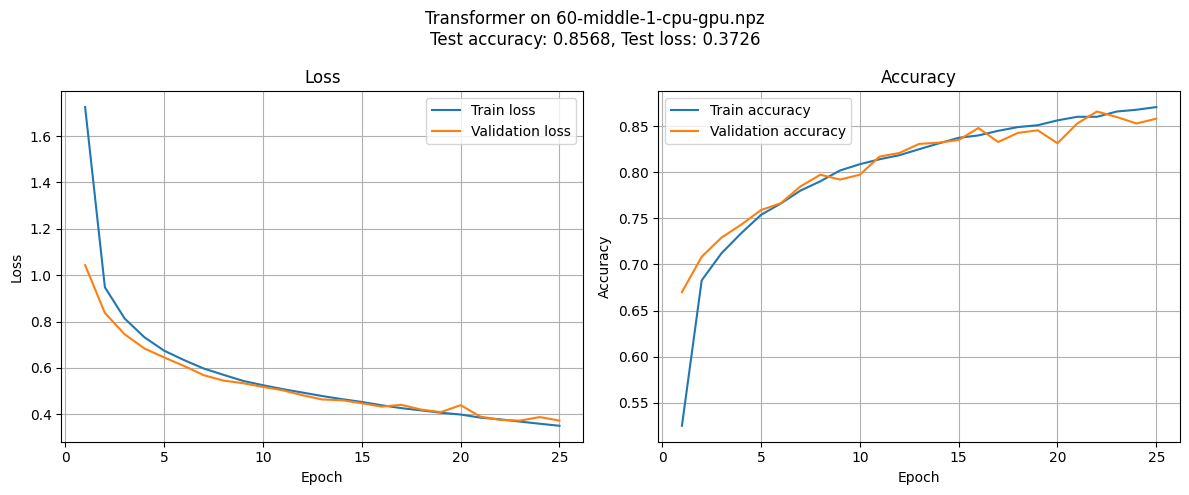

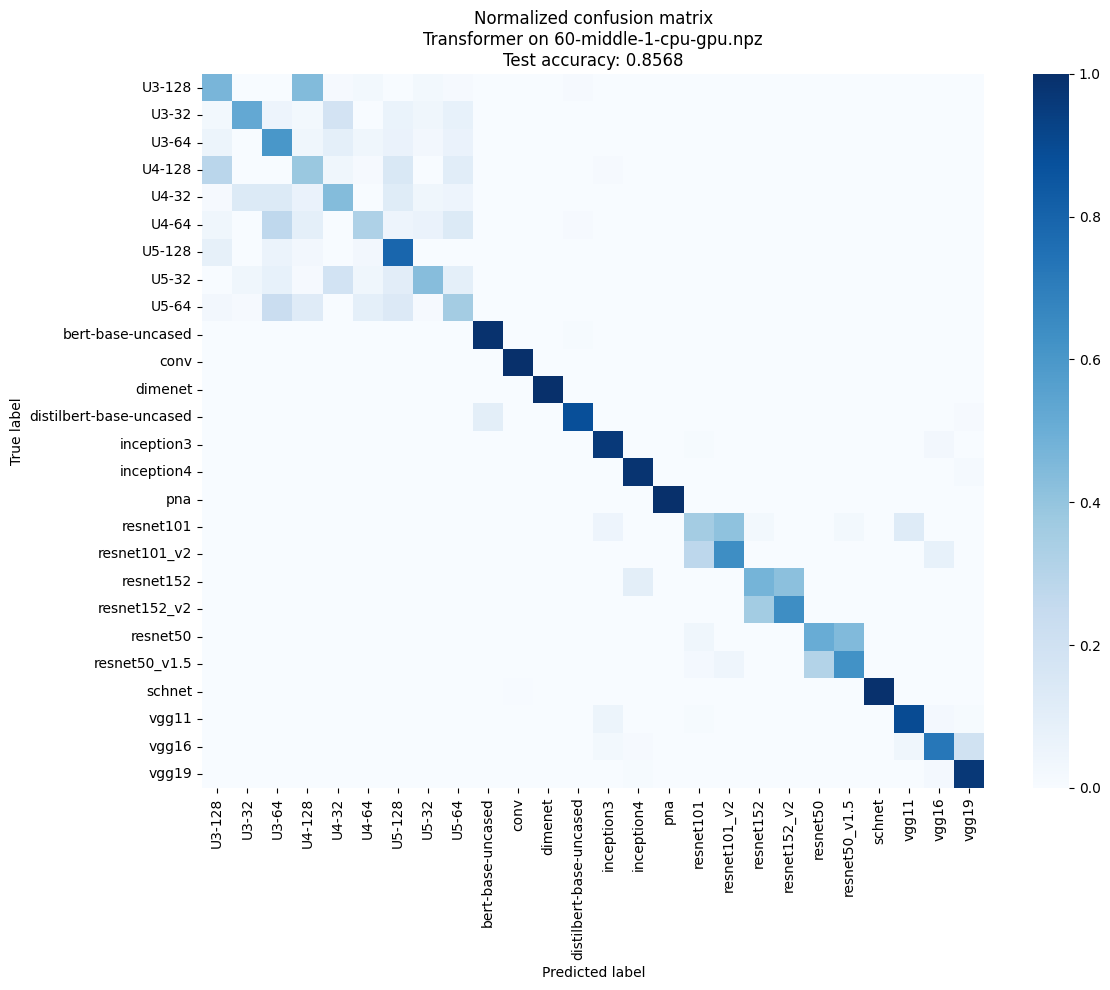

Worst run:
Model: Transformer
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.8567810917276308
Test loss: 0.37263279684521067



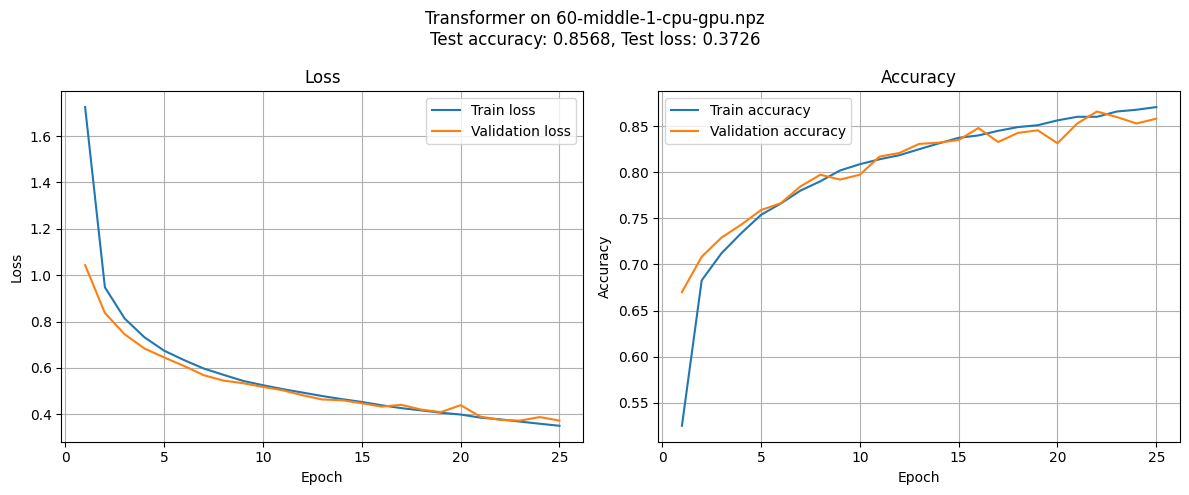

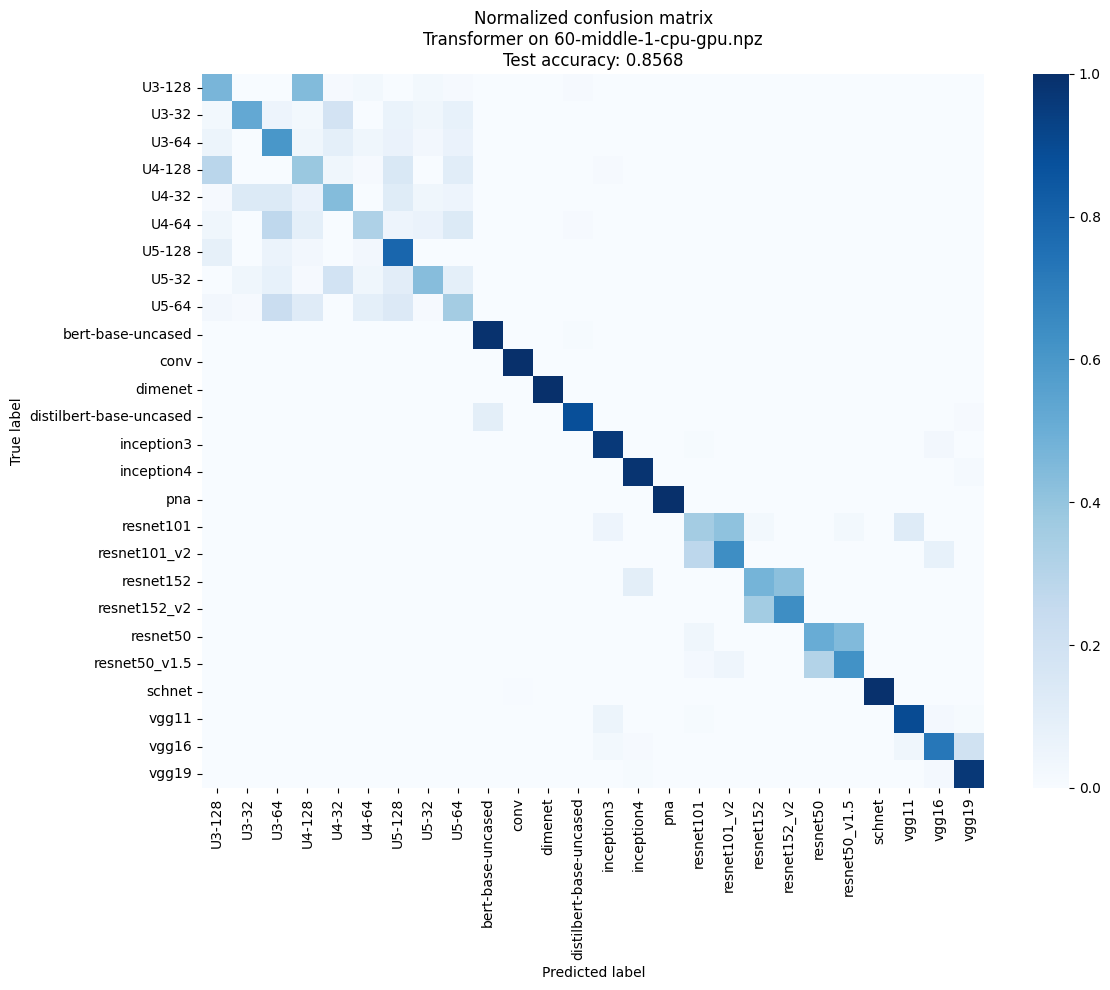

In [103]:
best_result, worst_result = plot_best_and_worst_runs(
    results_transformer,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Two Tower Transformer

In [58]:
results_two_tower = main(
    dataset_ls=middle_dataset,
    model_builder=build_two_tower_model,
    model_name="TwoTowerTransformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training TwoTowerTransformer on 60-middle-1-cpu-gpu.npz
Total parameters: 138,330
Trainable parameters: 138,330


100%|██████████| 89/89 [00:01<00:00, 67.11it/s]


Epoch [1/25] | Time: 24.67s
Train Loss: 1.4923 | Train Accuracy: 0.5913
Val Loss:   0.9382 | Val Accuracy:   0.6817


100%|██████████| 89/89 [00:01<00:00, 66.33it/s]


Epoch [6/25] | Time: 24.99s
Train Loss: 0.5493 | Train Accuracy: 0.8061
Val Loss:   0.5039 | Val Accuracy:   0.8139


...

Epoch [16/25] | Time: 24.98s
Train Loss: 0.3145 | Train Accuracy: 0.8782
Val Loss:   0.3204 | Val Accuracy:   0.8737


100%|██████████| 89/89 [00:01<00:00, 66.31it/s]


Epoch [21/25] | Time: 25.00s
Train Loss: 0.2659 | Train Accuracy: 0.8974
Val Loss:   0.2766 | Val Accuracy:   0.8913


100%|██████████| 112/112 [00:01<00:00, 66.59it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/TwoTowerTransformer_60-middle-1-cpu-gpu.pt
Test accuracy: 0.8959
Training duration: 10.42 min
Average epoch time: 25.00 sec
--------------------------------------------------------------------------------


Best run:
Model: TwoTowerTransformer
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.8958919527293191
Test loss: 0.2687127880487941



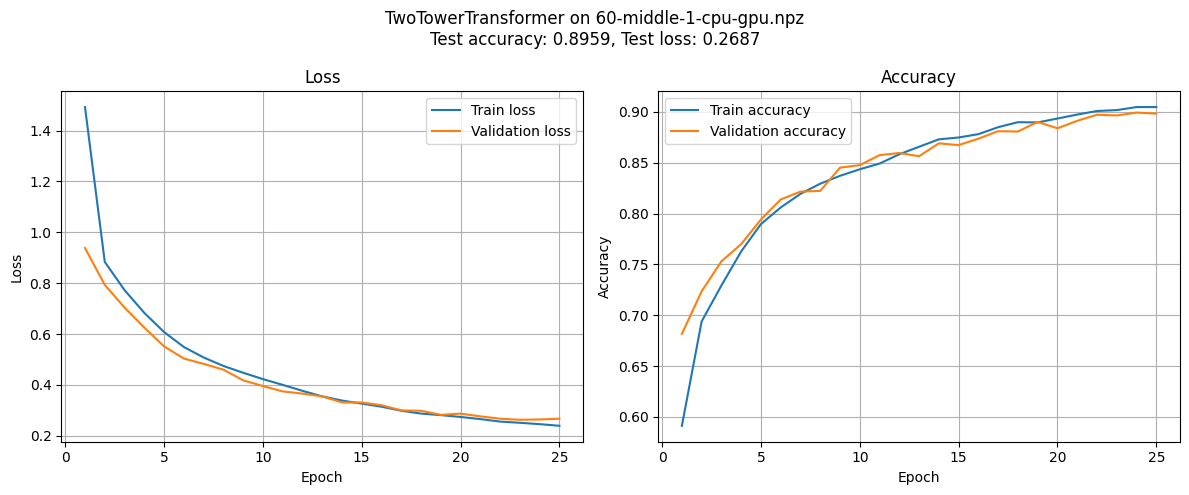

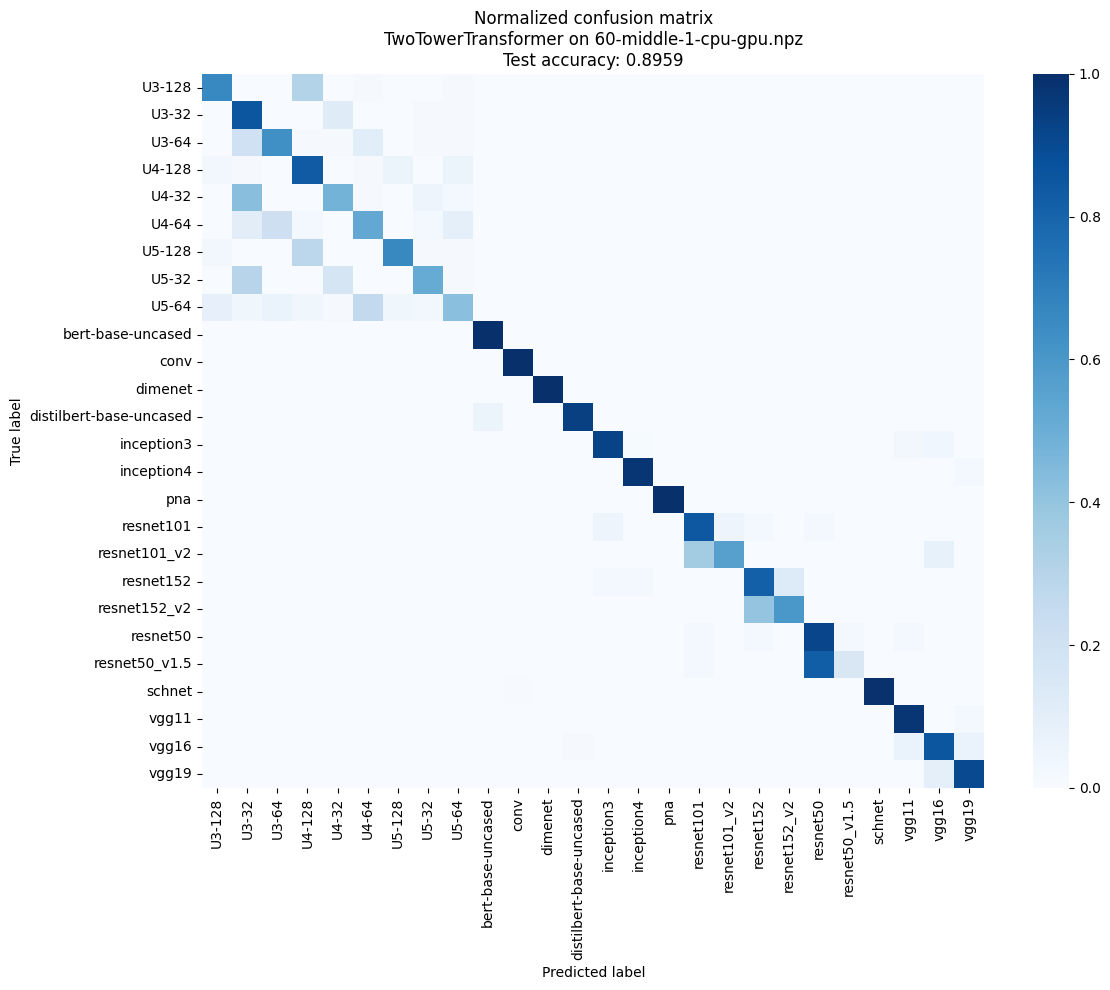

Worst run:
Model: TwoTowerTransformer
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.8958919527293191
Test loss: 0.2687127880487941



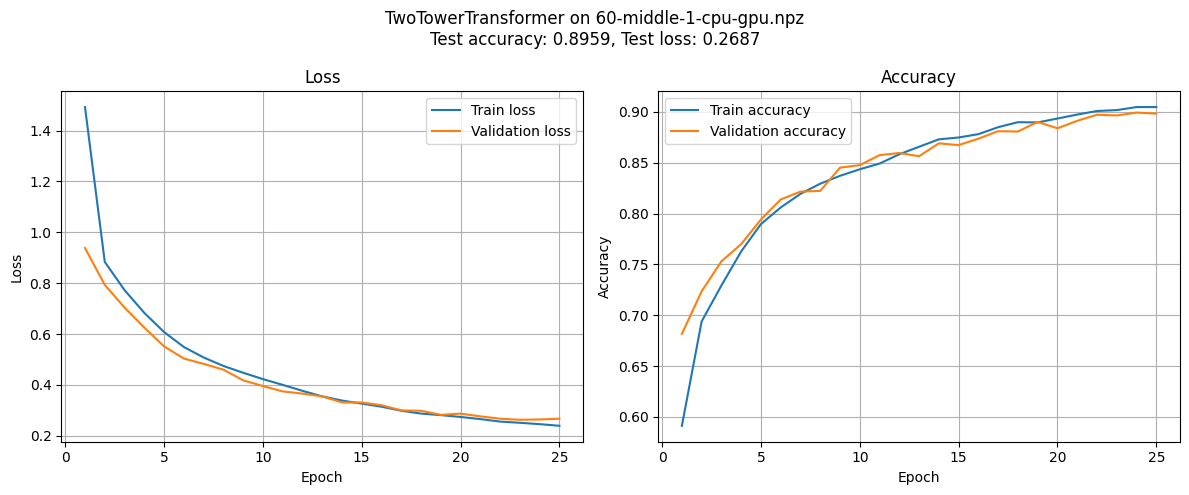

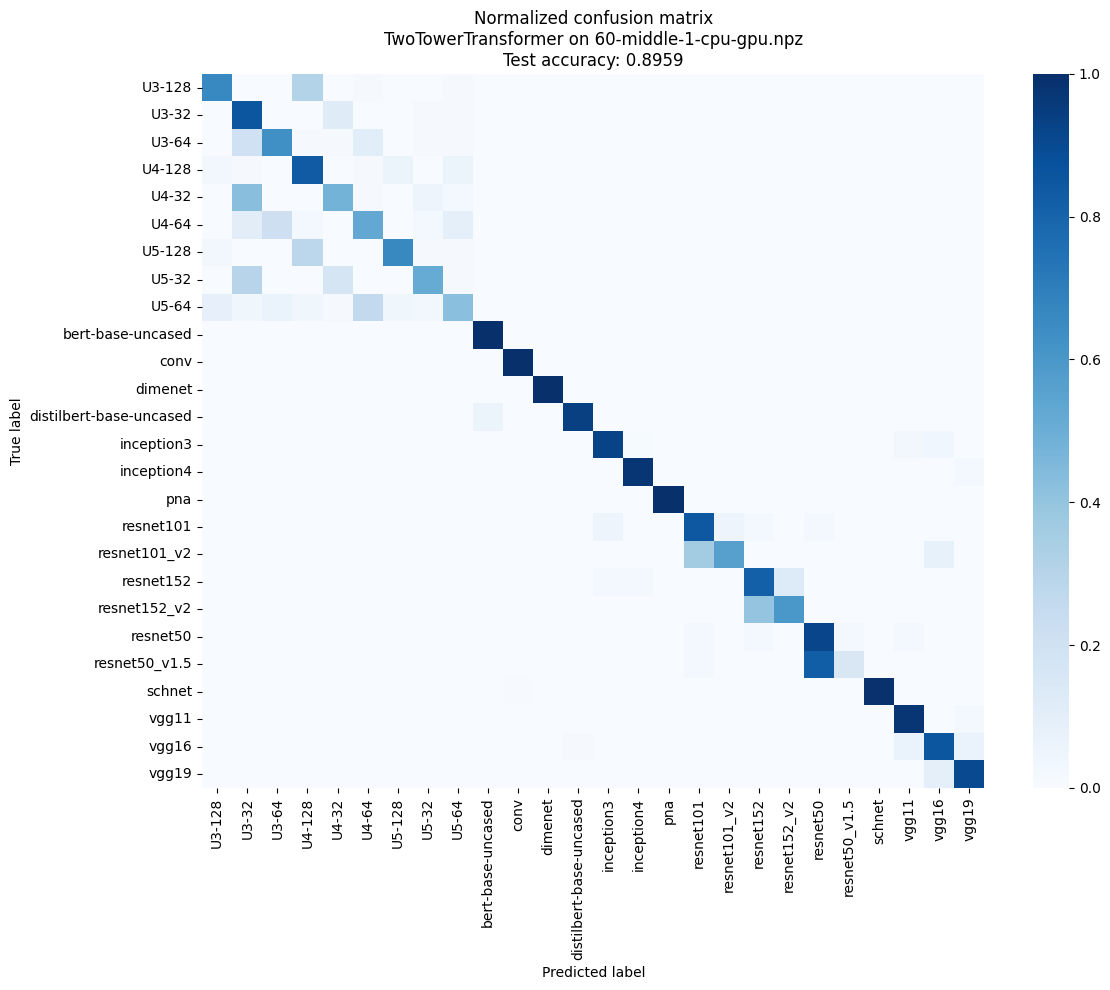

In [59]:
best_result, worst_result = plot_best_and_worst_runs(
    results_two_tower,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Gated Two Tower Transformer

In [112]:
middle_dataset = [
    d for d in separated_datasets
    if d["name"] == "60-middle-1-separate-cpu-gpu.npz"
]

In [113]:
results_gated = main(
    dataset_ls=middle_dataset,
    model_builder=build_gated_two_tower_model,
    model_name="GatedTwoTowerTransformer",
    separate=True,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training GatedTwoTowerTransformer on 60-middle-1-separate-cpu-gpu.npz
Total parameters: 144,922
Trainable parameters: 144,922


100%|██████████| 89/89 [00:00<00:00, 125.06it/s]


Epoch [1/25] | Time: 13.00s
Train Loss: 1.5309 | Train Accuracy: 0.5803
Val Loss:   0.9432 | Val Accuracy:   0.6757


100%|██████████| 89/89 [00:00<00:00, 126.43it/s]


Epoch [6/25] | Time: 12.87s
Train Loss: 0.5441 | Train Accuracy: 0.8039
Val Loss:   0.4888 | Val Accuracy:   0.8160


...

Epoch [16/25] | Time: 12.91s
Train Loss: 0.3307 | Train Accuracy: 0.8720
Val Loss:   0.3294 | Val Accuracy:   0.8684


100%|██████████| 89/89 [00:00<00:00, 124.52it/s]


Epoch [21/25] | Time: 12.91s
Train Loss: 0.2879 | Train Accuracy: 0.8813
Val Loss:   0.3095 | Val Accuracy:   0.8748


100%|██████████| 112/112 [00:00<00:00, 125.49it/s]


Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/GatedTwoTowerTransformer_60-middle-1-separate-cpu-gpu.pt
Test accuracy: 0.8765
Training duration: 5.39 min
Average epoch time: 12.94 sec
--------------------------------------------------------------------------------


Best run:
Model: GatedTwoTowerTransformer
Dataset: 60-middle-1-separate-cpu-gpu.npz
Test accuracy: 0.8764772087788407
Test loss: 0.29524486527878313



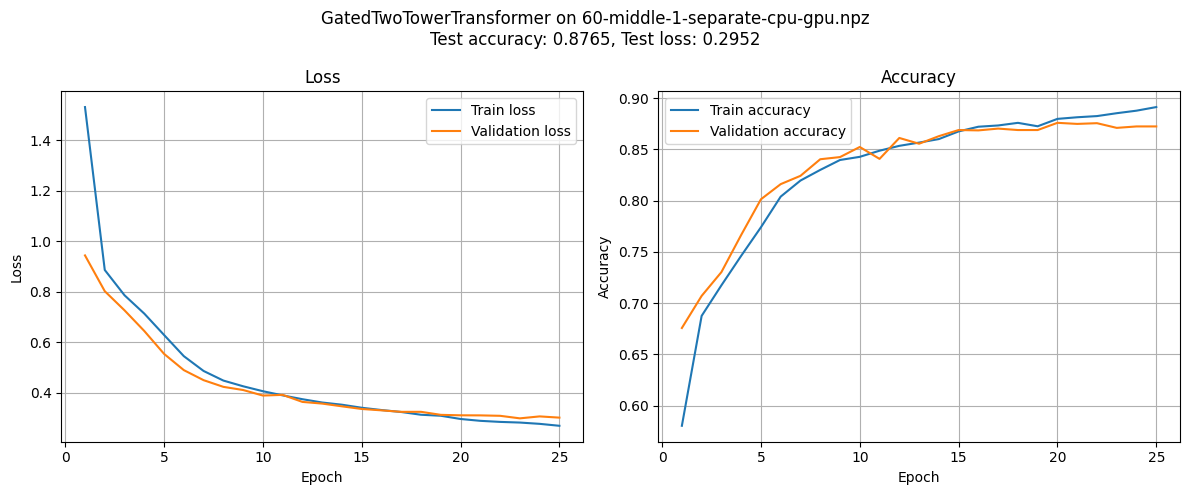

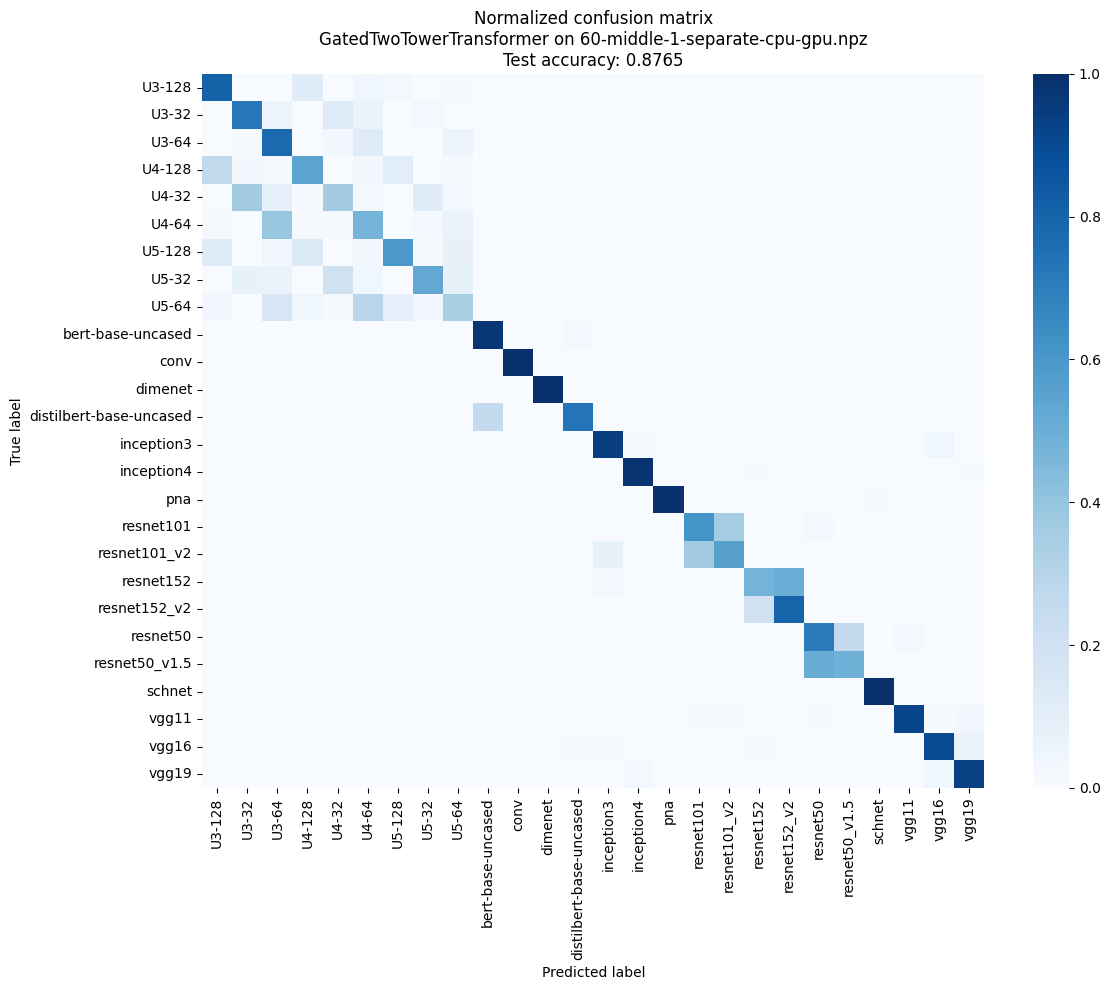

Worst run:
Model: GatedTwoTowerTransformer
Dataset: 60-middle-1-separate-cpu-gpu.npz
Test accuracy: 0.8764772087788407
Test loss: 0.29524486527878313



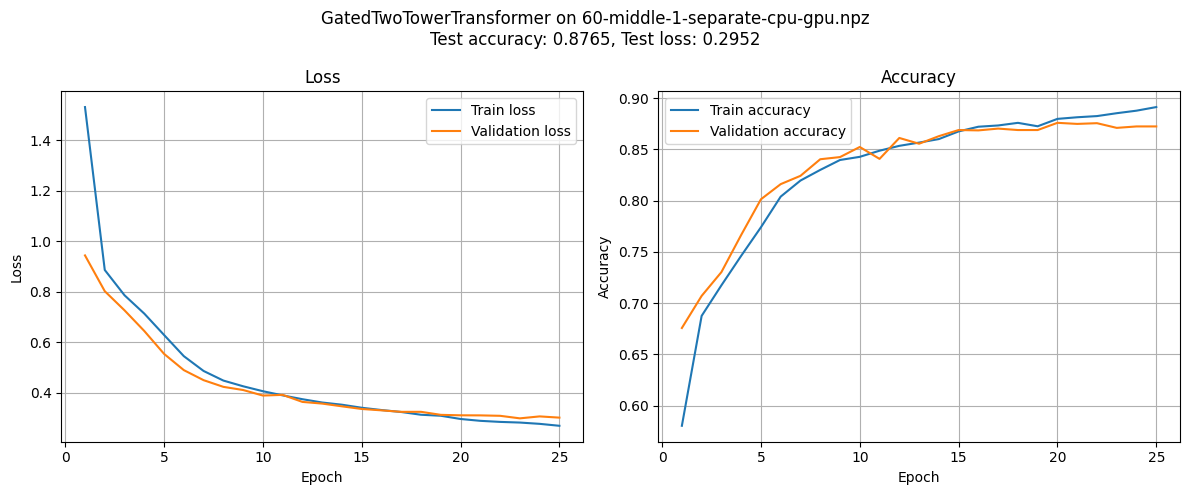

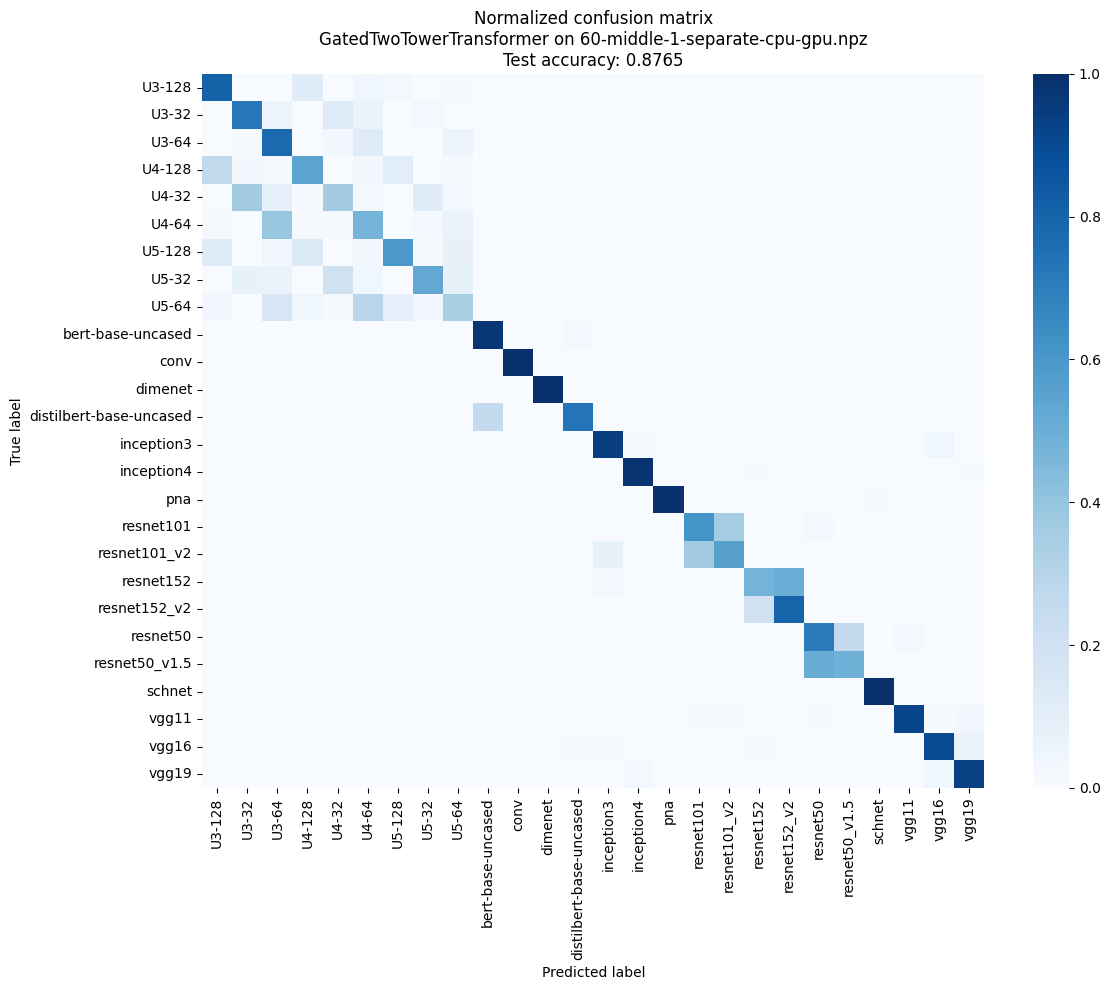

In [114]:
best_result, worst_result = plot_best_and_worst_runs(
    results_gated,
    metric="test_acc",
    class_names=class_names_separate,
    normalize_cm=True,
)

In [115]:
all_results = results_transformer + results_two_tower + results_gated

In [117]:
summary_df = results_to_summary_df(all_results)
summary_df

,model_name,dataset_name,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec,model_path
0,Transformer,60-middle-1-cpu-gpu.npz,0.856781,0.372633,0.865987,0.858248,0.870800,25,69658,69658,317.637064,5.293951,12.705483,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
1,TwoTowerTransformer,60-middle-1-cpu-gpu.npz,0.895892,0.268713,0.899402,0.898347,0.904837,25,138330,138330,625.105245,10.418421,25.004210,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
2,GatedTwoTowerTransformer,60-middle-1-separate-cpu-gpu.npz,0.876477,0.295245,0.875835,0.872318,0.891205,25,144922,144922,323.410661,5.390178,12.936426,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...


In [118]:
summary_df.groupby("model_name").mean("test_acc").sort_values("test_acc", ascending=False)

,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec
model_name,,,,,,,,,,,
TwoTowerTransformer,0.895892,0.268713,0.899402,0.898347,0.904837,25.0,138330.0,138330.0,625.105245,10.418421,25.004210
GatedTwoTowerTransformer,0.876477,0.295245,0.875835,0.872318,0.891205,25.0,144922.0,144922.0,323.410661,5.390178,12.936426
Transformer,0.856781,0.372633,0.865987,0.858248,0.870800,25.0,69658.0,69658.0,317.637064,5.293951,12.705483


In [119]:
efficiency_summary = (
    summary_df
    .groupby("model_name")
    .agg(
        avg_test_acc=("test_acc", "mean"),
        best_test_acc=("test_acc", "max"),
        avg_training_min=("training_duration_min", "mean"),
        avg_epoch_time_sec=("avg_epoch_time_sec", "mean"),
        avg_epochs_run=("num_epochs_run", "mean"),
        total_params=("total_params", "first"),
        trainable_params=("trainable_params", "first"),
    )
    .reset_index()
    .sort_values("avg_test_acc", ascending=False)
)

efficiency_summary

,model_name,avg_test_acc,best_test_acc,avg_training_min,avg_epoch_time_sec,avg_epochs_run,total_params,trainable_params
2,TwoTowerTransformer,0.895892,0.895892,10.418421,25.004210,25.0,138330,138330
0,GatedTwoTowerTransformer,0.876477,0.876477,5.390178,12.936426,25.0,144922,144922
1,Transformer,0.856781,0.856781,5.293951,12.705483,25.0,69658,69658


# Analyzing Attention layers

## TransformerModel

In [142]:
basic_transformer_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Transformer_60-middle-1-cpu-gpu.pt"

model_basic, attn_basic, inputs_basic, logits_basic = run_model_and_get_attention(
    model_path=basic_transformer_path,
    model_builder=build_transformer_model,
    dataloader=combined_datasets[2]["test_dl"],
    device=device,
    separate=False,
)

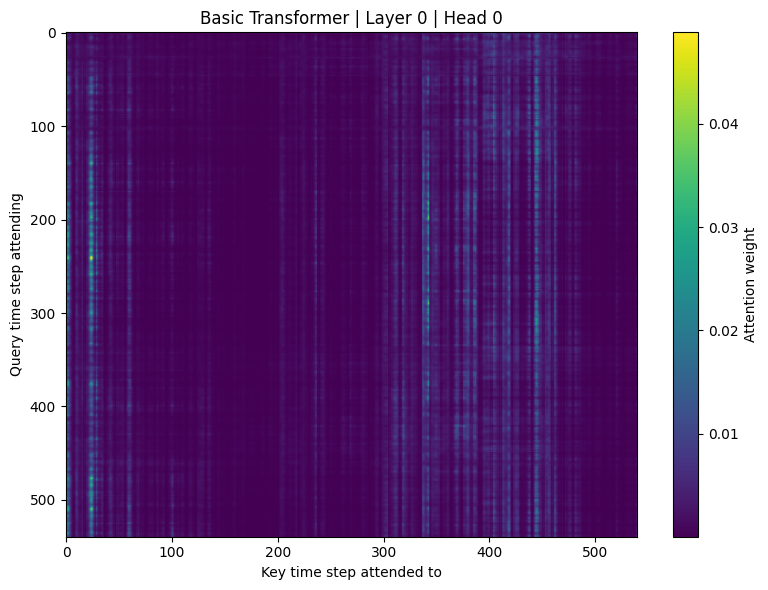

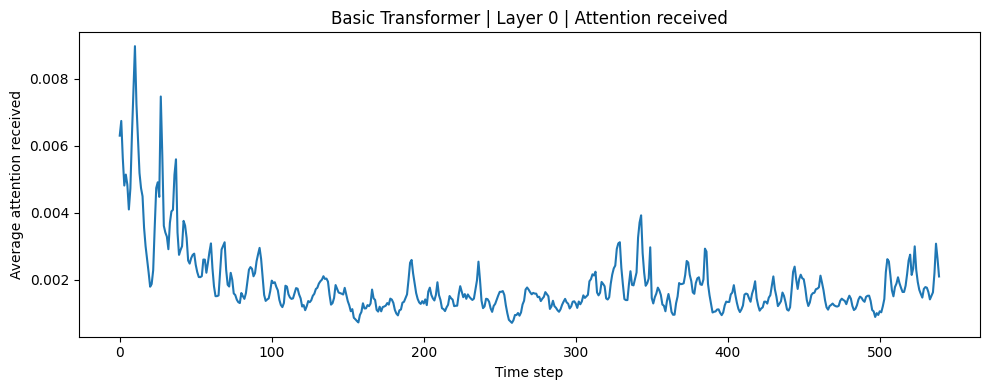

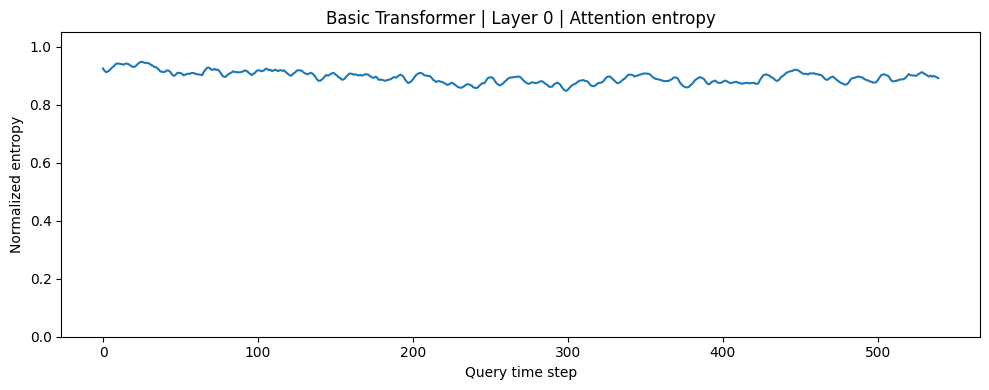

{'mean_normalized_entropy': 0.895284116268158, 'mean_topk_mass': 0.16065670549869537, 'mean_max_attention': 0.02925839275121689}


In [145]:
basic_layer0 = attn_basic["encoder"][0]

plot_attention_map(
    basic_layer0,
    sample_idx=0,
    head_idx=0,
    title="Basic Transformer | Layer 0 | Head 0",
)

plot_attention_received(
    basic_layer0,
    title="Basic Transformer | Layer 0 | Attention received",
)

plot_attention_entropy_by_query(
    basic_layer0,
    title="Basic Transformer | Layer 0 | Attention entropy",
)

print(attention_summary_stats(basic_layer0, top_k=10))

## GatedTwoTowerTransformer

In [146]:
gated_path = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/GatedTwoTowerTransformer_60-middle-1-separate-cpu-gpu.pt"

model_gated, attn_gated, inputs_gated, logits_gated = run_model_and_get_attention(
    model_path=gated_path,
    model_builder=build_gated_two_tower_model,
    dataloader=separated_datasets[1]["test_dl"],
    device=device,
    separate=True,
)

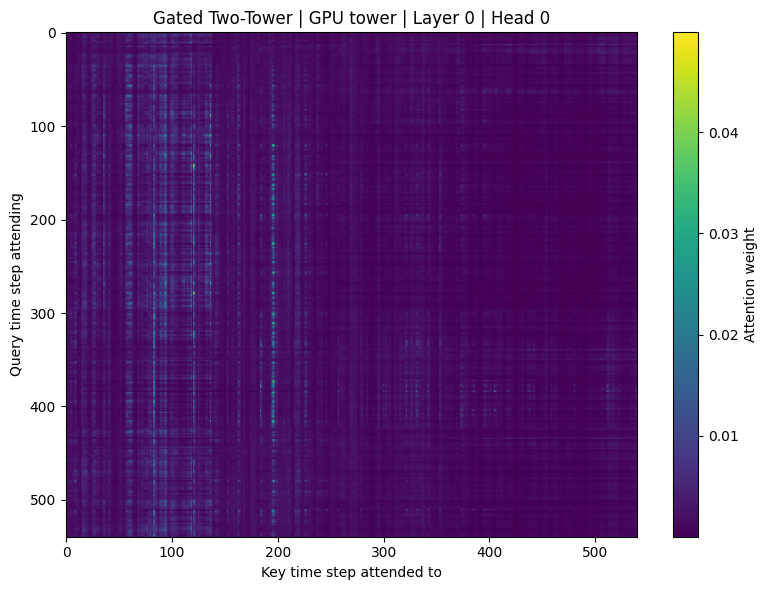

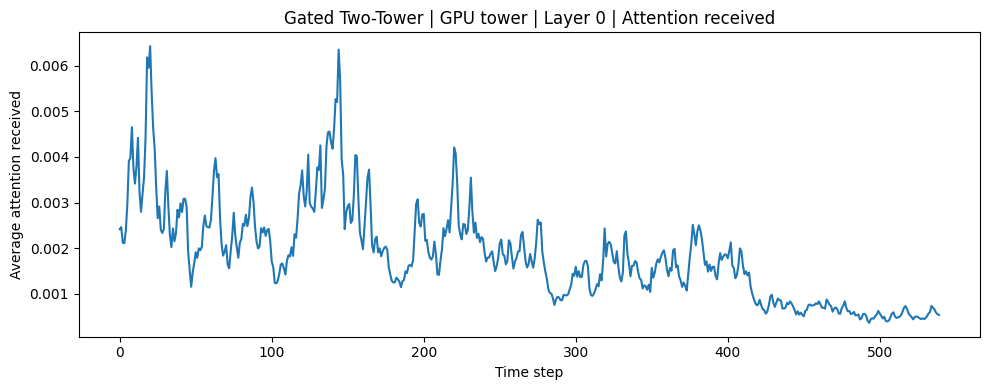

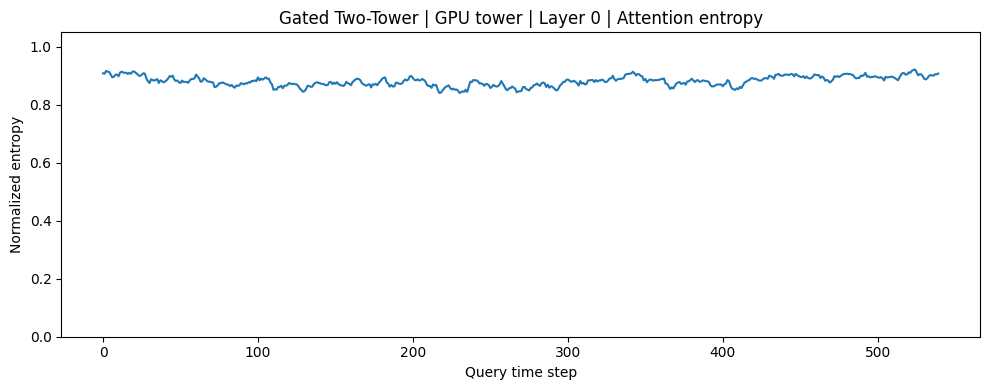

GPU attention stats:
{'mean_normalized_entropy': 0.8814557194709778, 'mean_topk_mass': 0.1611466258764267, 'mean_max_attention': 0.02682451903820038}


In [148]:
gpu_layer0 = attn_gated["gpu"][0]

plot_attention_map(
    gpu_layer0,
    sample_idx=0,
    head_idx=0,
    title="Gated Two-Tower | GPU tower | Layer 0 | Head 0",
)

plot_attention_received(
    gpu_layer0,
    title="Gated Two-Tower | GPU tower | Layer 0 | Attention received",
)

plot_attention_entropy_by_query(
    gpu_layer0,
    title="Gated Two-Tower | GPU tower | Layer 0 | Attention entropy",
)

print("GPU attention stats:")
print(attention_summary_stats(gpu_layer0, top_k=10))

In [ ]:
cpu_layer0 = attn_gated["cpu"][0]

plot_attention_map(
    cpu_layer0,
    sample_idx=0,
    head_idx=0,
    title="Gated Two-Tower | CPU tower | Layer 0 | Head 0",
)

plot_attention_received(
    cpu_layer0,
    title="Gated Two-Tower | CPU tower | Layer 0 | Attention received",
)

plot_attention_entropy_by_query(
    cpu_layer0,
    title="Gated Two-Tower | CPU tower | Layer 0 | Attention entropy",
)

print("CPU attention stats:")
print(attention_summary_stats(cpu_layer0, top_k=10))

## Comparing all layers and towers in a table

In [151]:
basic_attn_summary_df = summarize_attention_maps(
    attn_basic,
    model_name="Transformer",
    top_k=5,
)

gated_attn_summary_df = summarize_attention_maps(
    attn_gated,
    model_name="GatedTwoTowerTransformer",
    top_k=5,
)

attention_summary_df = pd.concat(
    [basic_attn_summary_df, gated_attn_summary_df],
    ignore_index=True,
)

attention_summary_df

,model_name,tower,layer,mean_normalized_entropy,mean_topk_mass,mean_max_attention
0,Transformer,encoder,0,0.895284,0.102319,0.029258
1,Transformer,encoder,1,0.878367,0.120470,0.040751
2,GatedTwoTowerTransformer,gpu,0,0.881456,0.098167,0.026825
3,GatedTwoTowerTransformer,gpu,1,0.916807,0.077366,0.026197
4,GatedTwoTowerTransformer,cpu,0,0.897261,0.915359,0.319895
5,GatedTwoTowerTransformer,cpu,1,0.971420,0.889403,0.231262
